# 

# Calculate titers of H5 HA pseudotyped lentiviruses

In [1]:
import os
import warnings

import math
import numpy as np 

from IPython.display import display, HTML
import matplotlib.pyplot as plt

from neutcurve.colorschemes import CBMARKERS, CBPALETTE
from mizani.formatters import scientific_format

import pandas as pd
from pandas.api.types import CategoricalDtype

from plotnine import *
import altair as alt
from pandas.api.types import CategoricalDtype



In [2]:
plt.rcParams['svg.fonttype'] = 'none'

In [3]:
warnings.simplefilter('ignore')

In [4]:
pwd()

'/fh/fast/bloom_j/computational_notebooks/bdadonai/2025/Flu_H5N1_American-Wigeon_2021_HA_MHCII_binding_DMS/analysis_notebooks/H5_pseudovirus_entry_validations_on_different_cell_lines'

Read config


In [5]:
titers = pd.read_csv('data/virus_titer_RLU.csv')

titers = (titers
          .assign(RLUperuL=lambda x: x['RLU_per_well'] / x['uL_virus']
                 )
         )

display(HTML(titers.head().to_html(index=False)))

replicate,virus,dilution,uL_virus,RLU_per_well,cells,oseltamivir,media,ng_neuraminidase,entry_effect,RLUperuL
rep1,D77E,0.50000,50.000,129400000,293-SA23,no,D10,150,MHCII decrease,2588000.0
rep1,D77E,0.25000,25.000,116300000,293-SA23,no,D10,150,MHCII decrease,4652000.0
rep1,D77E,0.12500,12.500,77470000,293-SA23,no,D10,150,MHCII decrease,6197600.0
rep1,D77E,0.06250,6.250,54810000,293-SA23,no,D10,150,MHCII decrease,8769600.0
rep1,D77E,0.03125,3.125,30730000,293-SA23,no,D10,150,MHCII decrease,9833600.0


In [6]:
ncol=min(8, titers['virus'].nunique())
nrow=math.ceil(titers['virus'].nunique() / ncol)

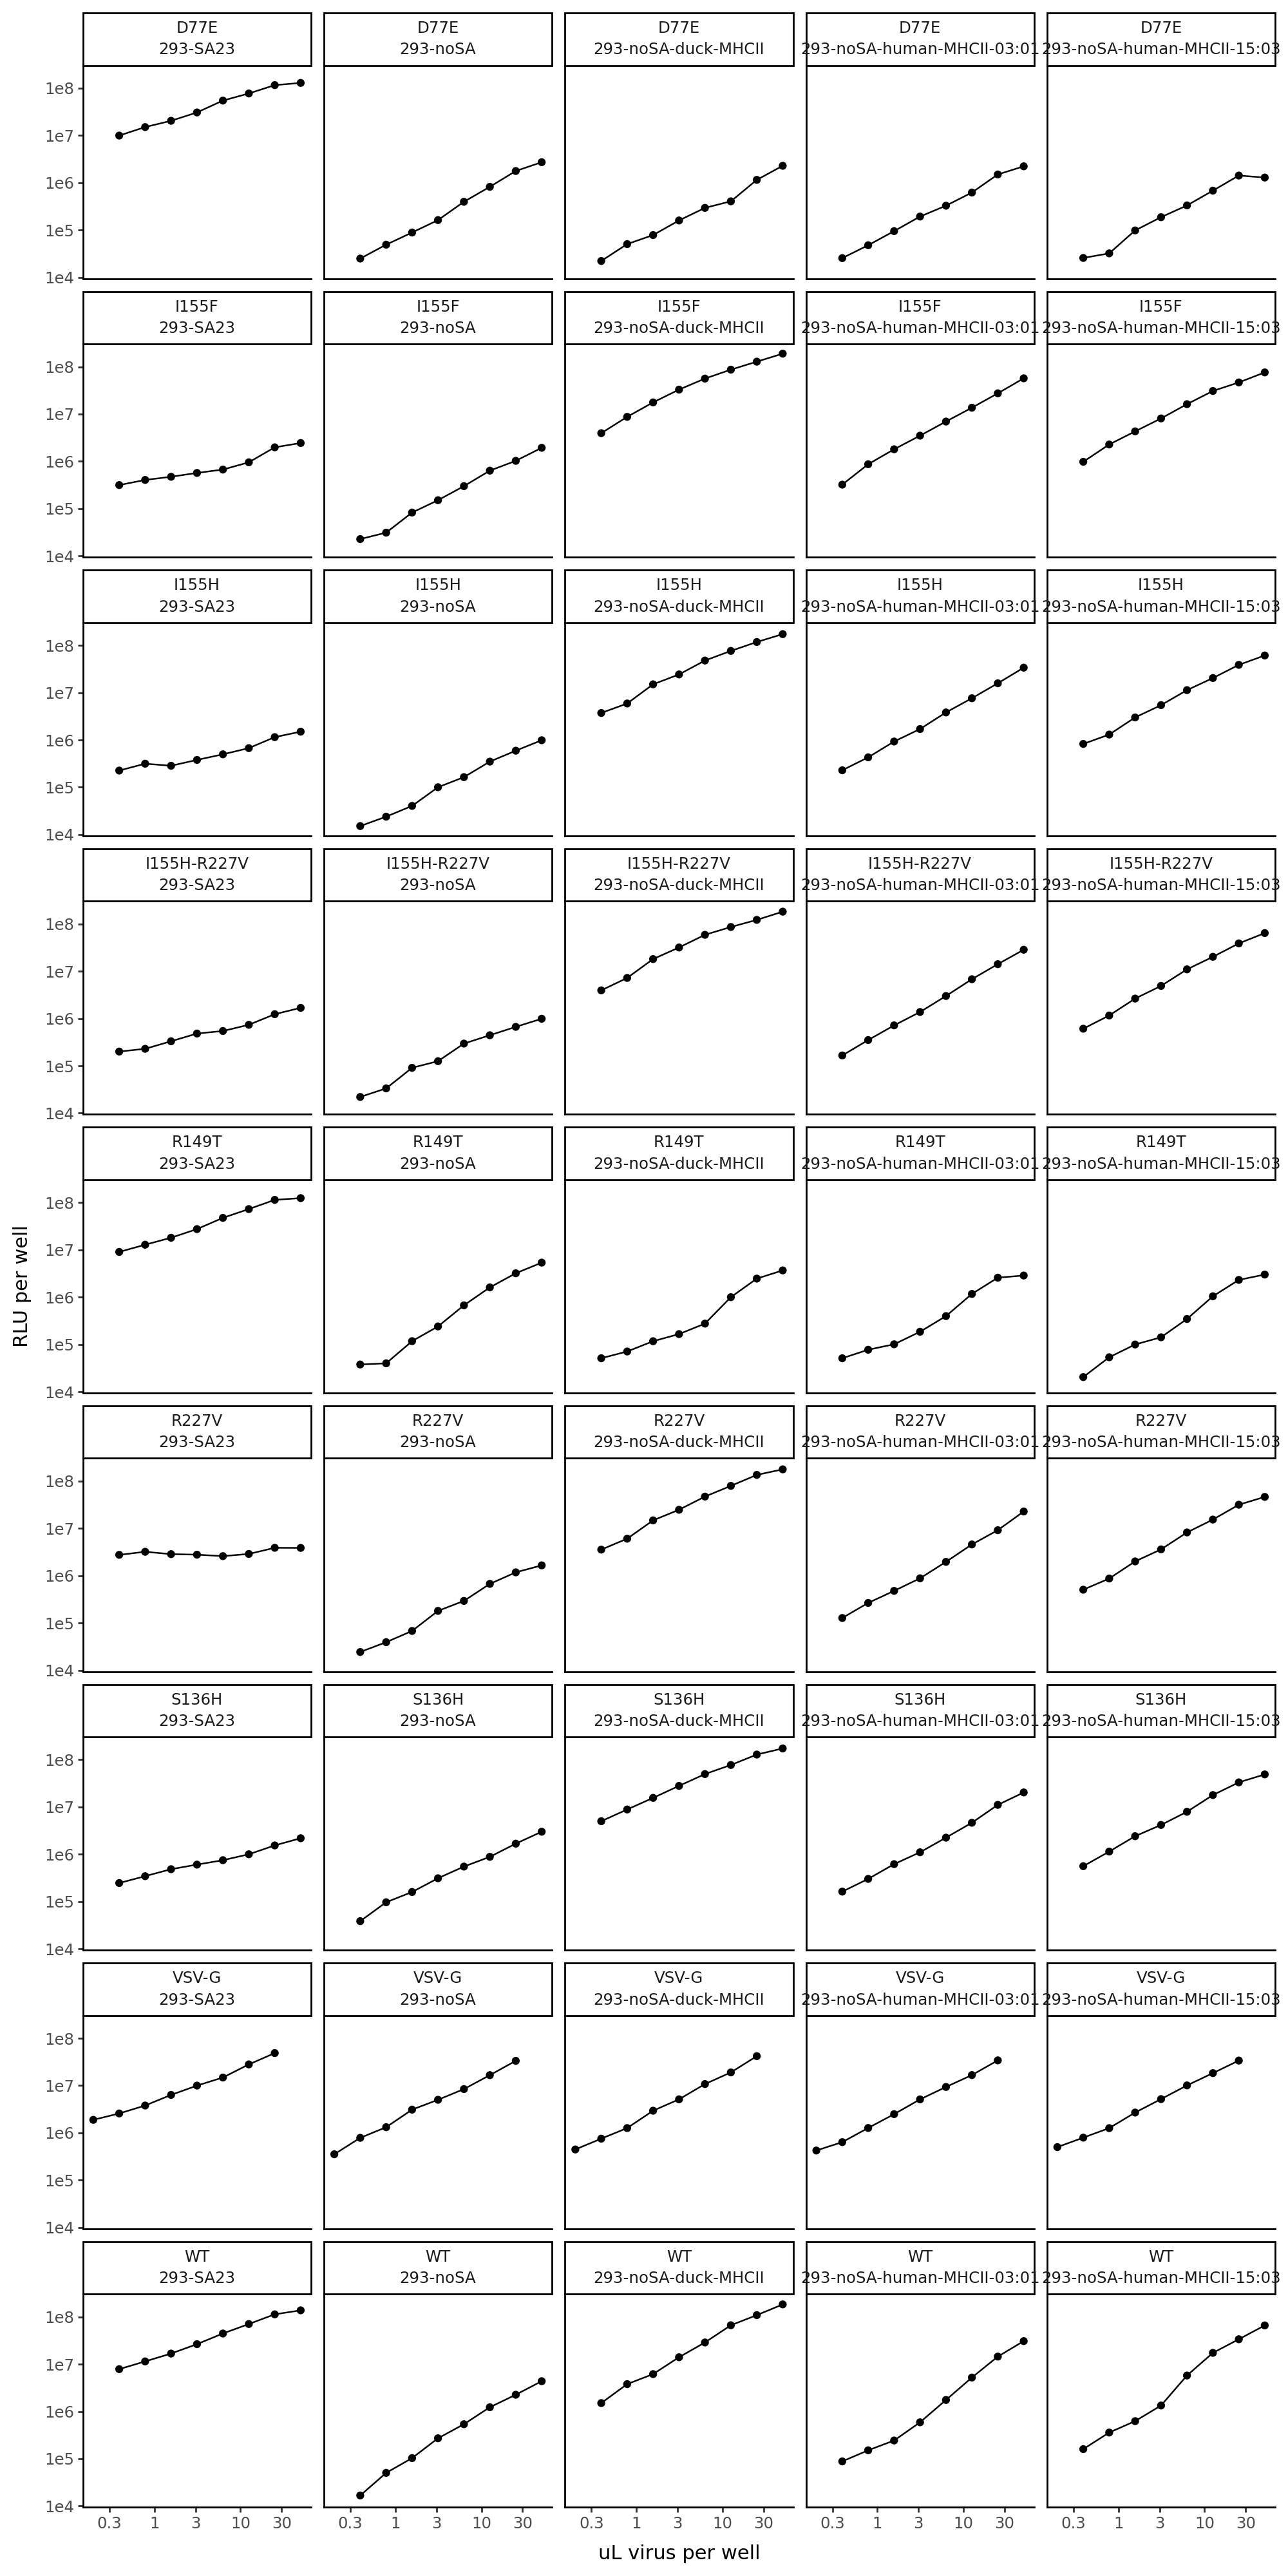

In [7]:
p = (ggplot(titers.dropna()
            ) +
     aes('uL_virus', 'RLU_per_well') +
     geom_point(size=1.5) +
     geom_line() +
     facet_wrap('~virus+cells', ncol=5) +
     scale_y_log10(name='RLU per well') +
     scale_x_log10(name='uL virus per well') +
     theme_classic() +
     theme(axis_text_x=element_text(),
           figure_size=(10,20),
           )
     )

p

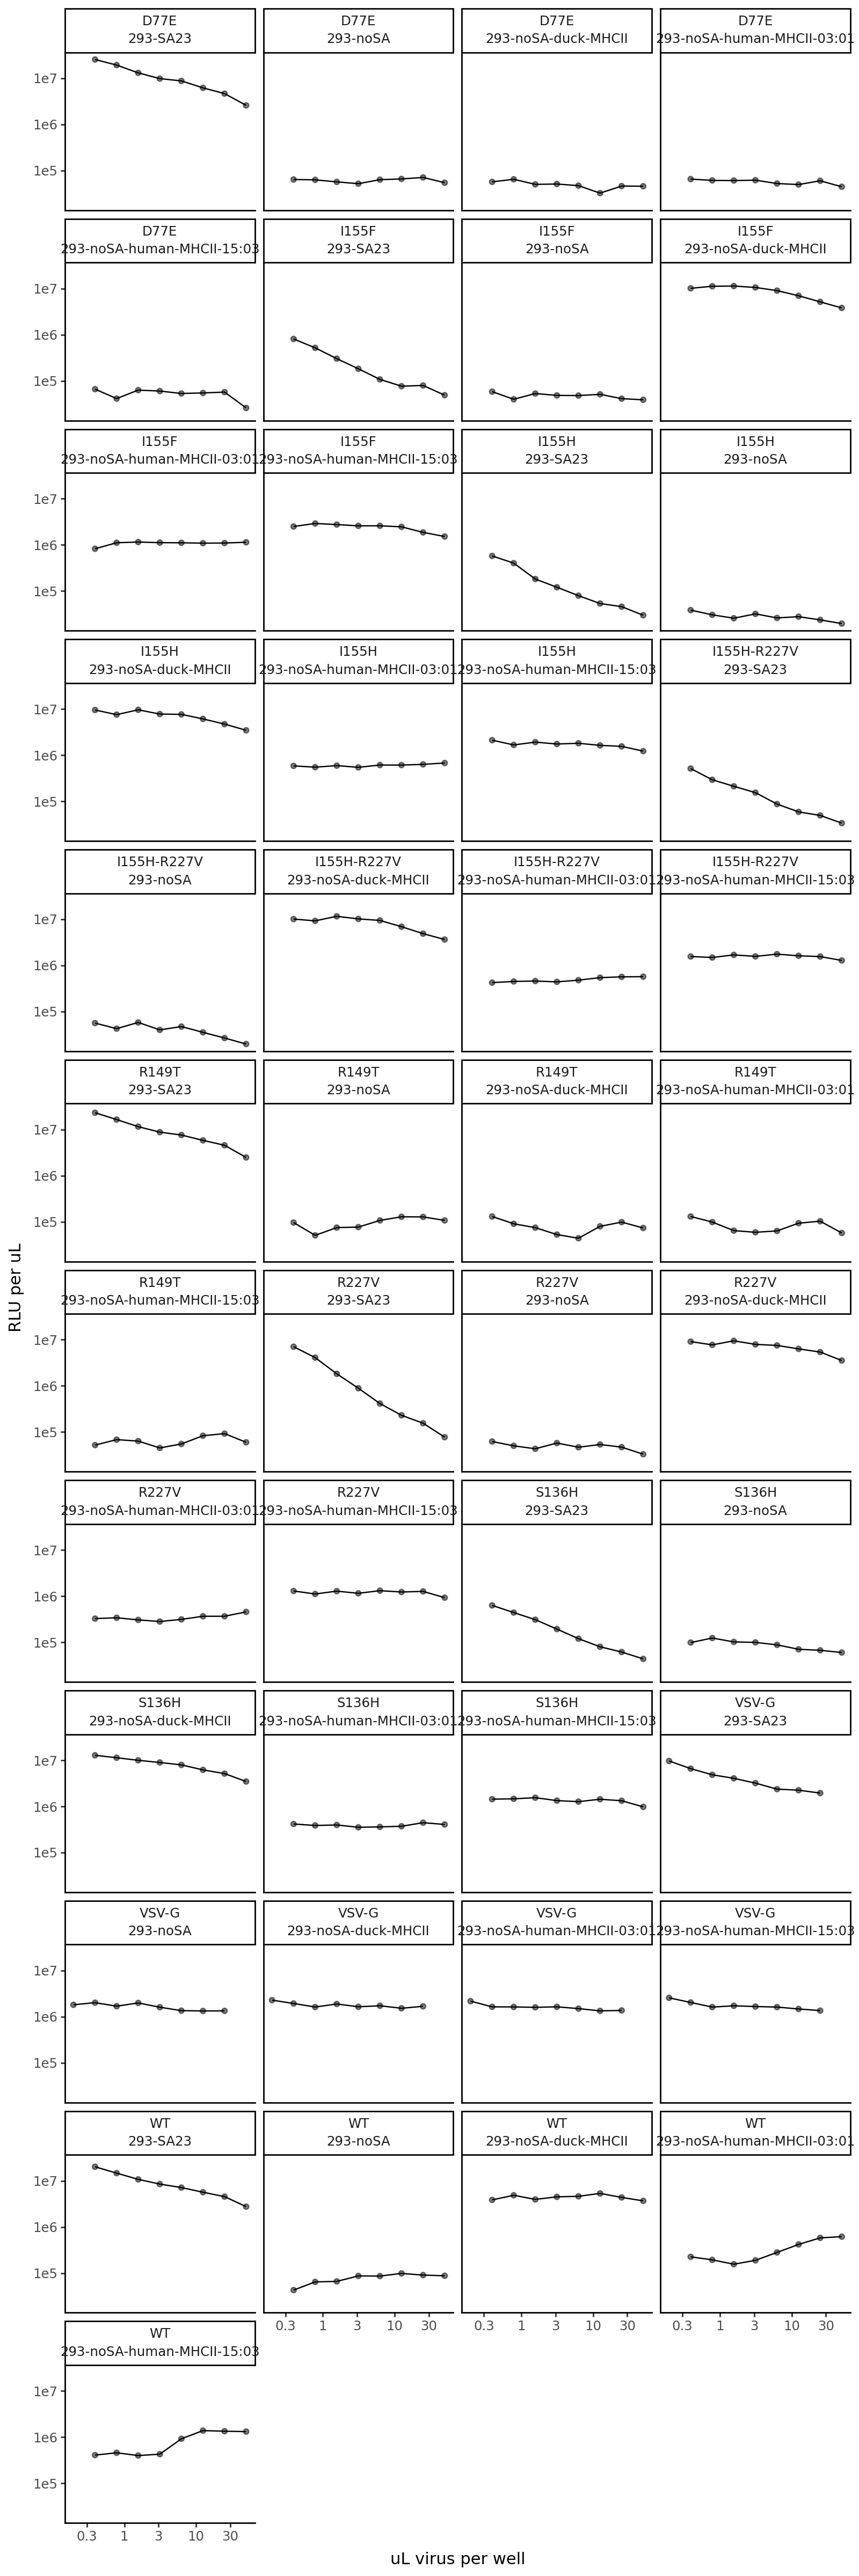

In [8]:
p = (ggplot(titers.dropna()
            ) +
     aes('uL_virus', 'RLUperuL', group='replicate') +
     geom_point(size=1.5, alpha=0.5) +
     geom_line() +
     facet_wrap('~virus+cells', ncol=4) +
     scale_y_log10(name='RLU per uL') +
     scale_x_log10(name='uL virus per well') +
     theme_classic() +
     theme(axis_text_x=element_text(),
           figure_size=(8,24),
           ) 
     )

p

Check that above plots are approximately linear 

In [9]:
average_titers = (titers
                  .dropna() # missing values for some replicates
                  # .query('uL_virus > 9') # drop concentrations that would not be linear
                  .groupby(['virus', "cells", 'oseltamivir', 'media', 'ng_neuraminidase', 'entry_effect'])
                  .agg(mean_RLUperuL=pd.NamedAgg(column='RLUperuL', aggfunc=np.mean))
                  .reset_index()
                 )
average_titers.to_csv('virus_titers.csv', index=False)

display(HTML(average_titers.head().to_html(index=False)))

virus,cells,oseltamivir,media,ng_neuraminidase,entry_effect,mean_RLUperuL
D77E,293-SA23,no,D10,150,MHCII decrease,11244300.0
D77E,293-noSA,no,D10,150,MHCII decrease,61336.9
D77E,293-noSA-duck-MHCII,no,D10,150,MHCII decrease,49312.3
D77E,293-noSA-human-MHCII-03:01,no,D10,150,MHCII decrease,57009.0
D77E,293-noSA-human-MHCII-15:03,no,D10,150,MHCII decrease,52571.8


In [10]:

# keep virus order if already categorical; otherwise use appearance order
virus_order = average_titers["virus"].drop_duplicates().tolist()

chart = (
    alt.Chart(average_titers)
    .mark_point(size=400, filled=True, opacity=0.5, stroke="black", strokeWidth=1.2)
    .encode(
        x=alt.X(
            "virus:N",
            sort=virus_order,
            title=None,
            axis=alt.Axis(labelAngle=90, labelFontSize=14, labelLimit=300),
        ),
        y=alt.Y(
            "mean_RLUperuL:Q",
            scale=alt.Scale(type="log", domain=[1, 1e8]),
            title="RLU per µL",
            axis=alt.Axis(titleFontSize=14, labelFontSize=12),
        ),
        color=alt.Color(
            "cells:N",
            scale=alt.Scale(range=CBPALETTE),
            legend=alt.Legend(title="cells", titleFontSize=13, labelFontSize=12, orient="bottom", labelLimit=300),
        ),
        tooltip=["virus:N", "cells:N", alt.Tooltip("mean_RLUperuL:Q", format=".2e")],
    )
    .properties(
        width=700,
        height=400,
        title="MHCII cell entry validation",
    )
)

hline = (
    alt.Chart(pd.DataFrame({"y": [500]}))
    .mark_rule(strokeDash=[6, 6], color="black")
    .encode(y="y:Q")
)

chart = (
    (chart + hline)
    .configure_axis(grid=False)
    .configure_view(stroke=None)
    .configure_title(fontSize=16)
)

chart

alt.LayerChart(...)

In [11]:
# ── Save chart as html ─────────────────────────────────────────────────────────
OUTPUT_html= './virus_titers.html'
# save as HTML
chart.save(OUTPUT_html)
print(f"✓ Chart saved as HTML: {OUTPUT_html}")

✓ Chart saved as HTML: ./virus_titers.html


In [12]:

virus_order = [
    'WT', 'VSV-G', 'D77E', 'R149T', 'S136H',
    'I155F', 'I155H', 'R227V', 'I155H-R227V', 'Q142W'
]

cells_order = [
    '293-SA23', '293-noSA', '293-noSA-duck-MHCII',
    '293-noSA-human-MHCII-15:03', '293-noSA-human-MHCII-03:01'
]

In [13]:
CBPALETTE = ('#E69F00','#999999','#56B4E9','#009E73','#F0E442','#0072B2','#D55E00','#CC79A7')

average_titers = average_titers.copy()

average_titers["virus"] = average_titers["virus"].astype(
    CategoricalDtype(categories=virus_order, ordered=True)
)

average_titers["cells"] = average_titers["cells"].astype(
    CategoricalDtype(categories=cells_order, ordered=True)
)

base = alt.Chart(average_titers).encode(
    x=alt.X(
        "cells:N",
        sort=cells_order,
        title=None,
        axis=alt.Axis(
            labelAngle=90,
            labelFontSize=14,
            labelLimit=0
        ),
    ),
    y=alt.Y(
        "mean_RLUperuL:Q",
        scale=alt.Scale(type="log", domain=[10000, 1e8]),
        title="RLU per µL",
        axis=alt.Axis(
            titleFontSize=14,
            labelFontSize=12,
            format=".0e"
        ),
    ),
    color=alt.Color(
        "entry_effect:N",
        scale=alt.Scale(range=CBPALETTE),
        legend=alt.Legend(
            title="entry_effect",
            orient="bottom",
            titleFontSize=13,
            labelFontSize=12,
            labelLimit=0
        ),
    ),
    tooltip=[
        "virus:N",
        "cells:N",
        "entry_effect:N",
        alt.Tooltip("mean_RLUperuL:Q", format=".2e"),
    ],
)

points = base.mark_point(
    size=300,
    filled=True,
    opacity=0.9,
    stroke="black",
    strokeWidth=1,
)


chart = (
    alt.layer(points)
    .properties(
        width=180,
        height=180
    )
    .facet(
        column=alt.Column(
            "virus:N",
            sort=virus_order,
            header=alt.Header(
                title=None,
                labelFontSize=18,
                labelOrient="top",
            ),
        ),
        columns=4,
    )
    .properties(
        title="variant titers on different cell lines"
    )
    .resolve_scale(
        y="shared"
    )
    .configure_axis(
        grid=False
    )
    .configure_view(
        stroke=None
    )
    .configure_title(
        fontSize=16
    )
    .configure_facet(
        spacing=20
    )
)

chart

alt.FacetChart(...)

In [14]:
# ── Save chart as html ─────────────────────────────────────────────────────────
OUTPUT_html= './virus_titers_by_variant.html'
# save as HTML
chart.save(OUTPUT_html)
print(f"✓ Chart saved as HTML: {OUTPUT_html}")

✓ Chart saved as HTML: ./virus_titers_by_variant.html


In [15]:
CBPALETTE = ('#E69F00','#56B4E9','#999999','#009E73','#F0E442','#0072B2','#D55E00','#CC79A7')

df = average_titers.copy()

# get baseline mean_RLUperuL for each virus in 293-noSA cells
baseline = (
    df.loc[df["cells"] == "293-noSA", ["virus", "mean_RLUperuL"]]
    .rename(columns={"mean_RLUperuL": "mean_RLUperuL_293_noSA"})
)

# join baseline back onto all rows by virus
df = df.merge(baseline, on="virus", how="left")

# keep only the cell lines you want to compare against 293-noSA
df = df[df["cells"].isin(cells_order)].copy()

# calculate fold-change over 293-noSA
df["RLU_over_293_noSA"] = df["mean_RLUperuL"] / df["mean_RLUperuL_293_noSA"]

# set ordering
df["virus"] = df["virus"].astype(
    CategoricalDtype(categories=virus_order, ordered=True)
)

df["cells"] = df["cells"].astype(
    CategoricalDtype(categories=cells_order, ordered=True)
)

df["virus"] = df["virus"].astype(
    CategoricalDtype(categories=virus_order, ordered=True)
)

df["cells"] = df["cells"].astype(
    CategoricalDtype(categories=cells_order, ordered=True)
)

base = alt.Chart(df).encode(
    x=alt.X(
        "cells:N",
        sort=cells_order,
        title=None,
        axis=alt.Axis(
            labelAngle=90,
            labelFontSize=14,
            labelLimit=0
        ),
    ),
    y=alt.Y(
        "RLU_over_293_noSA:Q",
        scale=alt.Scale(type="log", domain=[1, 300]),
        title="mean_RLUperuL / mean_RLUperuL in 293-noSA",
        axis=alt.Axis(
            titleFontSize=14,
            labelFontSize=12
        ),
    ),
    color=alt.Color(
        "entry_effect:N",
        sort=virus_order,
        scale=alt.Scale(range=CBPALETTE),
        legend=alt.Legend(
            title="entry_effect",
            orient="bottom",
            titleFontSize=13,
            labelFontSize=12,
            labelLimit=0
        ),
    ),
    tooltip=[
        "virus:N",
        "cells:N",
        alt.Tooltip("RLU_over_293_noSA:Q"),
    ],
)

points = base.mark_point(
    size=300,
    filled=True,
    opacity=0.9,
    stroke="black",
    strokeWidth=1,
)

hline = alt.Chart(df).mark_rule(
    strokeDash=[6, 6],
    color="black"
).encode(
    y=alt.datum(1)
)

chart = (
    alt.layer(hline, points)
    .properties(
        width=180,
        height=180
    )
    .facet(
        column=alt.Column(
            "virus:N",
            sort=virus_order,
            header=alt.Header(
                title=None,
                labelFontSize=18,
                labelOrient="top",
            ),
        ),
        columns=4,
    )
    .properties(
        title="change in titers compared to 293-noSA"
    )
    .resolve_scale(
        y="shared"
    )
    .configure_axis(
        grid=False
    )
    .configure_view(
        stroke=None
    )
    .configure_title(
        fontSize=16
    )
    .configure_facet(
        spacing=20
    )
)

chart

alt.FacetChart(...)

In [16]:
# ── Save chart as html ─────────────────────────────────────────────────────────
OUTPUT_html= './increase_over_noSA_by_variant.html'
# save as HTML
chart.save(OUTPUT_html)
print(f"✓ Chart saved as HTML: {OUTPUT_html}")

✓ Chart saved as HTML: ./increase_over_noSA_by_variant.html
